In [1]:
import jax.numpy as jnp

import sys

sys.path.append("./siegel_analyses/scripts/")
sys.path.insert(1,'./ibl_analyses/scripts/')

import netrep_helpers as nh
import utils
import loader
import setup
import matplotlib.pyplot as plt

import seaborn as sns
%load_ext autoreload
%autoreload 2
import scipy.stats as sts
import numpy as np
import pandas as pd
from scipy.spatial.distance import squareform
from scipy.cluster import hierarchy
from sklearn.manifold import MDS
from sklearn.decomposition import PCA

import imp
imp.reload(setup)
imp.reload(loader)
imp.reload(utils)
import tqdm
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import psychofit as psy
from pathlib import Path
import pickle

import matplotlib as mpl
new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
mpl.rcParams.update(new_rc_params)


### FIGURES 1-4 MAIN IBL ANALYSIS

In [2]:
def convert_to_rw_choices(cs_trials):
    choices = []
    for subject in cs_trials:
        left = subject[:,:5] == -1
        right = subject[:,5:] == 1
        both = np.column_stack([left.astype(int), right.astype(int)])
        print(both.shape)
        choices.append(np.mean(both,0))
    return np.array(choices)

def distances_mantel(dist1, dist2, n_perm=1000, seed=None):
    corrs_shuffle = []
    S = dist1.shape[0]
    flat_dist1 = dist1[np.triu_indices(S,1)]
    rng = np.random.default_rng(seed)
    for i in range(n_perm):
        perm = rng.permutation(S)
        shuffled_dist2 = dist2[perm, :][:, perm]
        flat_dist2_s = shuffled_dist2[np.triu_indices(S,1)]
        r_s,_ = sts.pearsonr(flat_dist2_s, flat_dist1)
        corrs_shuffle.append(r_s)
    return corrs_shuffle



In [3]:
# Load the data
DATA_DIR = Path.cwd() / "data_fig"
all_dist_neural = np.load(DATA_DIR / "all_dist_neural.npy", allow_pickle=True)
all_dist_cc = np.load(DATA_DIR / "all_dist_cc.npy", allow_pickle=True)
all_c_corrs = np.load(DATA_DIR / "all_c_corrs.npy", allow_pickle=True)

In [4]:
# Load the data - no cv
DATA_DIR = Path.cwd() / "data_fig"
dist_neural_nocv = np.load(DATA_DIR / "dist_neural_nocv.npy", allow_pickle=True)
dist_cc_nocv = np.load(DATA_DIR / "dist_cc_nocv.npy", allow_pickle=True)
choices = np.load(DATA_DIR / "choices.npy", allow_pickle=True)

Mean 1.4476771910892992, cdf 0.9261463240974844


/tmp/ipykernel_2706466/453579441.py:106: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


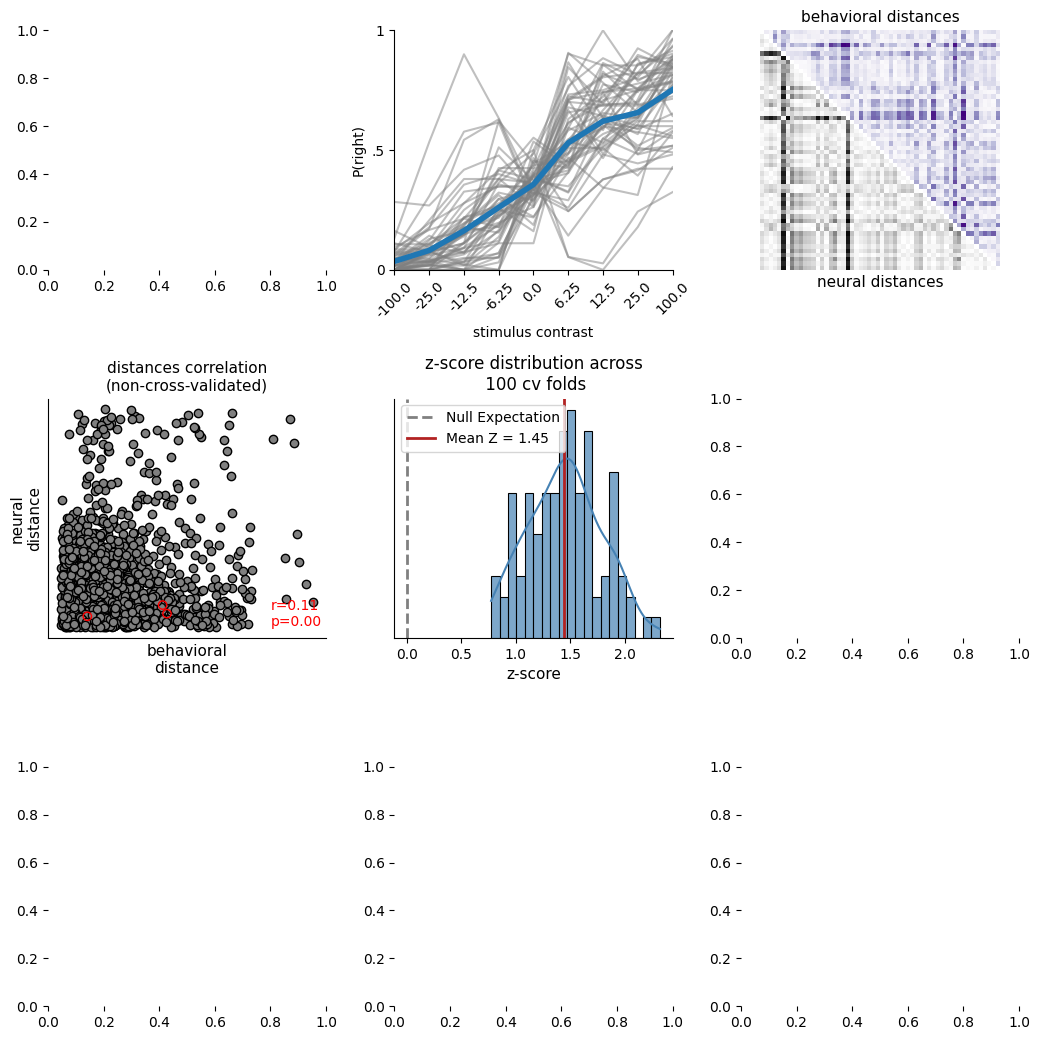

In [6]:
# FIGURE 1-4
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(7*1.5,7*1.5), constrained_layout=True)
sns.despine(left=True, bottom=True)

# Adding to the figure 
examples_idx= [10,12,19]
axes = axes.flatten()

### First - PSYCHOMETRIC CURVES
contrast = [-100.  ,  -25.  ,  -12.5 ,   -6.25,    0.  ,    6.25,   12.5 ,
         25.  ,  100.  ]

axes[1].plot(choices.T, color='gray', alpha=0.5)
axes[1].plot(np.nanmean(choices,0), lw=4)   
axes[1].set_ylabel("P(right)")
axes[1].set_xlabel("stimulus contrast")
axes[1].set_xticks(range(len(contrast)),contrast,rotation=45)
axes[1].set_yticks([0,0.5,1],[0,'.5',1])
axes[1].set_ylim(0,1)
axes[1].set_xlim(0,8)
sns.despine(bottom=False, left=False, ax=axes[1])

data_corrs = np.array(all_c_corrs)[:,0]
dist_neural = all_dist_neural[np.argmax(data_corrs)].copy()
dist_cc = all_dist_cc[np.argmax(data_corrs)].copy()

### Second - DISTANCE MATRICES
dist_neural = np.asarray(dist_neural, dtype=float)
dist_cc = np.asarray(dist_cc, dtype=float)
dist_neural_ = dist_neural.copy()
dist_cc_ = dist_cc.copy()
dist_neural_[np.triu_indices(dist_neural.shape[0], 0)] = np.nan
dist_cc_[np.tril_indices(dist_neural.shape[0], 0)] = np.nan

axes[2].imshow(dist_neural_,cmap="Grays")

axes[2].set_xlabel("neural distances", fontsize=11)

axes[2].set_title('behavioral distances', fontsize=11)
axes[2].imshow(dist_cc_,cmap="Purples")
axes[2].set_xticks([])
axes[2].set_yticks([])
axes[2].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False,left=False,labelleft=False,right=True,labelright=True)

#change ticks fontsize
for ti,tick in enumerate(axes[2].get_xticklabels()):
    tick.set_fontsize(8)
    axes[2].get_yticklabels()[ti].set_fontsize(8)
    #axes[1].get_xticklabels()[ti].set_fontsize(8)
    #axes[1].get_yticklabels()[ti].set_fontsize(8)


### Third - SCATTER PLOT OF DISTANCES
# take upper triangle for the non-cross-validated data
S = dist_neural_nocv.shape[0]
flat_dist_neural = dist_neural_nocv[jnp.triu_indices(S,1)]
flat_dist_cc = dist_cc_nocv[jnp.triu_indices(S,1)]

r_dist, p_dist = sts.pearsonr(flat_dist_cc,flat_dist_neural)

axes[3].scatter( flat_dist_cc,flat_dist_neural,color="k",facecolors='gray')
axes[3].text(1.5,0.1,"r={:.2f}\np={:.2f}".format(r_dist,p_dist),color="red")
axes[3].set_xlabel("behavioral\ndistance", fontsize=11)
axes[3].set_ylabel("neural\ndistance", fontsize=11)
axes[3].set_xticks([])
axes[3].set_yticks([])
axes[3].set_title("distances correlation\n(non-cross-validated)", fontsize=11)
axes[3].scatter(dist_cc[examples_idx,:][:,examples_idx][np.triu_indices(len(examples_idx),1)].flatten(),
                dist_neural[examples_idx,:][:,examples_idx][np.triu_indices(len(examples_idx),1)].flatten(),facecolors='none', edgecolors='red',zorder=10)
sns.despine(bottom=False, left=False, ax=axes[3])

### Fourth - DISTRIBUTION OF Z SCORES
from scipy.stats import norm
r = np.array(all_c_corrs[:, 0])
null_means = np.array([np.mean(c) for c in all_c_corrs[:, 1]])
null_stds = np.array([np.std(c) for c in all_c_corrs[:, 1]])

# Calculate Z-scores
z = (r - null_means) / null_stds

print(f'Mean {z.mean()}, cdf {norm.cdf(z.mean())}')

sns.histplot(
    z, 
    bins=20, 
    kde=True, 
    color="steelblue", 
    edgecolor="black", 
    alpha=0.7,
    ax=axes[4]
) 

#sns.kdeplot(null_means, color='orange', linewidth=2, alpha=0.7, ax=ax)

axes[4].axvline(0, color='gray', linestyle='--', linewidth=2, label='Null Expectation')
axes[4].axvline(np.mean(z), color='firebrick', linestyle='-', linewidth=2, label=f'Mean Z = {np.mean(z):.2f}')

axes[4].set_yticks([])
axes[4].set_yticklabels([])
axes[4].set_ylabel('')
axes[4].set_xlabel('z-score', fontsize=11)
axes[4].set_title('z-score distribution across\n 100 cv folds', fontsize=12)
axes[4].legend(frameon=True, facecolor='white')
sns.despine(bottom=False, left=False, ax=axes[4])

plt.tight_layout()
plt.savefig('IBL_distances.svg',dpi=300)
plt.show()


### Distances across regions

In [2]:
# Load the data
DATA_DIR = Path.cwd() / "data_fig"
means_dist_subject = np.load(DATA_DIR / "means_dist_subject.npy", allow_pickle=True)

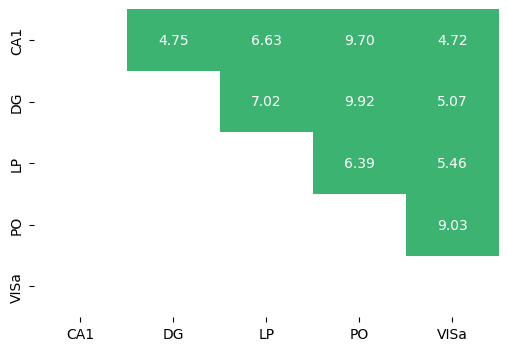

In [3]:
import matplotlib.colors as mcolors
means_dist = np.nanmean(means_dist_subject, axis=0)
regions = np.array(['CA1', 'DG', 'LP', 'PO', 'VISa'])
p_cell = np.full((len(regions), len(regions)), np.nan)

for r, reg in enumerate(regions):
    for c in range(r+1, len(regions)):
        mean_cc = means_dist[c, c]
        mean_rr = means_dist[r, r]

        dist = means_dist_subject[:, r, c]
        # test whether the distribution of the d(r,c) across subjects is significantly bigger than the distribution of the biggest between r and c
        if mean_cc > mean_rr:
            t, p = sts.ttest_rel(dist, means_dist_subject[:, c, c], alternative='greater')
            # or should i do wilcoxon?
            w, p_w = sts.wilcoxon(dist, means_dist_subject[:, c, c], alternative='greater')
        else:
            t, p = sts.ttest_rel(dist, means_dist_subject[:, r, r], alternative='greater')
            w, p_w = sts.wilcoxon(dist, means_dist_subject[:, r, r], alternative='greater')
        p_cell[r, c] = p_w

means_dist[np.tril_indices(len(regions))] = np.nan

sig_matrix = np.where(p_cell < 0.05, 1.0, 0.0)

# Re-apply NaNs to the lower triangle and diagonal
sig_matrix[np.isnan(p_cell)] = np.nan

# Define two flat colors: [Color for False, Color for True]
cmap = mcolors.ListedColormap(['lightgrey', 'mediumseagreen'])

plt.figure(figsize=(6, 4))
sns.heatmap(sig_matrix, annot=means_dist, fmt=".2f", cmap=cmap, vmin=0, vmax=1,
            yticklabels=regions, xticklabels=regions, cbar=False)

plt.show()


### FIGURE 5 is the per-region correlation distibution plot

In [6]:
# Load
DATA_DIR = Path.cwd() / "data_fig"
region_info = pd.read_csv(DATA_DIR / 'region_info.csv')

In [7]:
region_info.groupby('region').agg({'corr': ['mean', 'std'], 'z-score': ['mean', 'std']})


corr             z-score          
            mean       std      mean       std
region                                        
CA1     0.105095  0.048603  1.275525  0.589532
DG      0.157771  0.050640  1.850544  0.572527
LP      0.037111  0.036819  0.321853  0.358439
PO      0.226678  0.049719  1.570658  0.330192
VISa    0.108896  0.039776  1.002646  0.359213

<Axes: xlabel='z-score', ylabel='Count'>

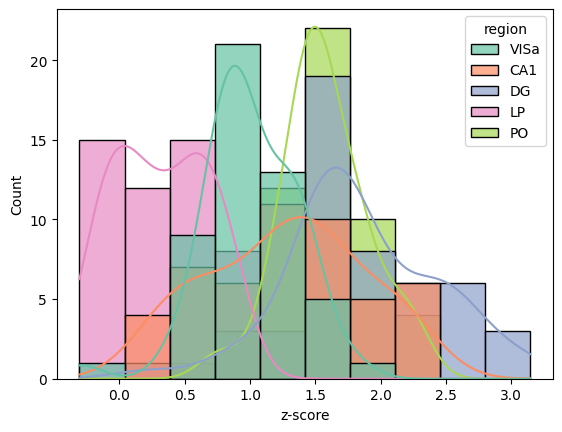

In [8]:
region_info
sns.histplot(
    data=region_info, 
    x="z-score", 
    hue="region", 
    bins=10, 
    kde=True, 
    palette=sns.color_palette("Set2", len(regions)),
    edgecolor="black", 
    alpha=0.7
)

/tmp/ipykernel_2707175/745561193.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="region", y="z-score", data=region_info, order=regions, palette=palette, ax=axes[5], inner='quartile', linewidth=1)
/tmp/ipykernel_2707175/745561193.py:38: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


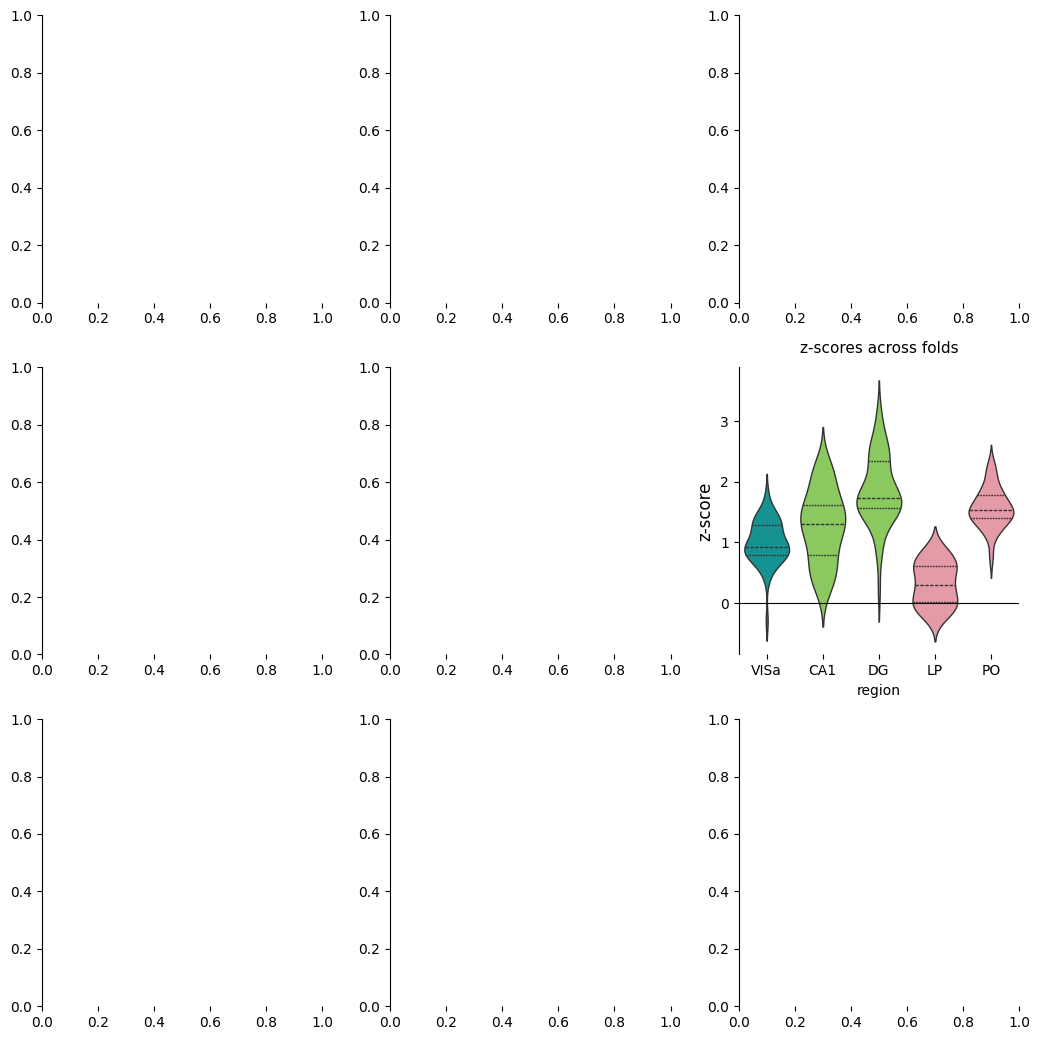

In [9]:
# FIGURE 5 
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(7*1.5,7*1.5), constrained_layout=True)

axes = axes.flatten()

colors = [ '#03A6A6', '#88D94E', '#88D94E', '#F28D9F', '#F28D9F']
palette = {'VISa': '#03A6A6', 'CA1': '#88D94E', 'DG': '#88D94E', 'LP': '#F28D9F', 'PO': '#F28D9F'}
#
# colors = ['#03A6A6', '#03A6A6', '#03A6A6', '#FF90FF', '#F28D9F']
# Plot distribution of correlations for each region
axes[5].set_title("z-scores across folds", fontsize=11, pad=10)

# Use palette only (remove explicit 'color' to let palette apply correctly)
sns.violinplot(x="region", y="z-score", data=region_info, order=regions, palette=palette, ax=axes[5], inner='quartile', linewidth=1)
axes[5].axhline(0, color='k', linewidth=.8)
axes[5].set_ylabel("z-score", fontsize=12)
#axes[5].set_yticks([0, 0.35])
#axes[5].set_ylim(-0.1, 0.38)

# Add significance stars where the lower 2.5% percentile of the distribution > 0
"""for i, region in enumerate(regions):
    vals = region_info.loc[region_info['region'] == region, 'z-score'].values
    if len(vals) == 0:
        continue
    lower = np.nanpercentile(vals, 2.5)

    if lower > 0:
        # compute a y position just above the data for this region
        ylim = axes[5].get_ylim()
        data_max = np.nanmax(vals)
        margin = 0.02 * (ylim[1] - ylim[0])
        y = data_max + margin
        # expand ylim if needed to make the star visible
        if y > ylim[1] - margin:
            axes[5].set_ylim(ylim[0], y + margin)
        axes[5].text(i, y+0.05, '*', ha='center', va='bottom', fontsize=14, color='k')
"""
plt.tight_layout()
sns.despine(bottom=True)

### Now, the last 3 figures are from ASD analysis

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, TSNE
from scipy.cluster import hierarchy
from collections import defaultdict
from matplotlib.lines import Line2D
from scipy.stats import ttest_rel

%load_ext autoreload
%autoreload 2
import imp
import sys
sys.path.insert(1, "./ibl_autism/")
from scripts.utils import load_animal_kernels, list_regions, list_animals, filter_kernels_outliers, filter_distributions_outliers
from matplotlib.colors import Normalize
from scripts.metric import dsd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
# Load 
DATA_DIR = Path.cwd() / "data_fig"
dist_neural_asd = np.load(DATA_DIR / "dist_neural_asd.npy", allow_pickle=True)
labels_arr = np.load(DATA_DIR / "labels_arr.npy", allow_pickle=True)


In [13]:
# FOR THE STATISTICAL TEST OF DIFFERENCES: get the neural distances and compute:
# 1. distance matrix within control (mean for each control subject to each other control subject)
# 2. distance matrix between each control and each other genotype (so, each control and the average distance between subjects of a genotype)
# 3. now you have #ControlSubjects references and 4 variations 

def within_distance(dist_matrix, labels, genotype):
    mask_g = labels == genotype
    within = dist_matrix[np.ix_(mask_g, mask_g)]
    np.fill_diagonal(within, np.nan) 
    return within

def across_distance(dist_matrix, labels, g1, g2):
    mask_g1 = labels == g1
    mask_g2 = labels == g2
    return dist_matrix[np.ix_(mask_g1, mask_g2)]

# Get mean distances for each control (first dimension) subject
control = np.nanmean(within_distance(dist_neural_asd, labels_arr, 'N'), axis=1)
control_vs_F = across_distance(dist_neural_asd, labels_arr, 'N', 'F').mean(axis=1)
control_vs_C = across_distance(dist_neural_asd, labels_arr, 'N', 'C').mean(axis=1)
control_vs_S = across_distance(dist_neural_asd, labels_arr, 'N', 'S').mean(axis=1)

# create a dataframe for plotting
df_control_distances = pd.DataFrame({
    'control_subject': np.arange(len(control)),
    'Within control': control,
    'Control vs S': control_vs_S,
    'Control vs F': control_vs_F,
    'Control vs C': control_vs_C,
})


In [14]:
def plot_mds_pca(dist_matrix, labels, n_components=50, ax=None):

    # DIstance matrices are not euclidean so PCA directly is not ideal
    # MDS on the distance matrix
    mds = MDS(n_components=n_components, 
              dissimilarity='precomputed', 
              random_state=66,
              normalized_stress=False,
              n_init=10,)
    
    mds_coords = mds.fit_transform(dist_matrix)

    #mds_coords = (mds_coords - mds_coords.mean(axis=0)) / mds_coords.std(axis=0)

    # PCA on MDS coordinates
    pca_2d = PCA(n_components=2, random_state=42)
    pca_coords = pca_2d.fit_transform(mds_coords)

    colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}
    map_labels = {'C':'Cntnap2', 'F':'Fmr1', 'N':'C57BL6', 'S':'Shank3'}

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    # PCA on MDS plot
    for g in np.unique(labels):
        mask = np.array(labels) == g
        ax.scatter(pca_coords[mask, 0], pca_coords[mask, 1],
                        c=colors[g], label=map_labels[g], s=60, edgecolors='white', linewidths=0.5)

    ax.set_xticks([])
    ax.set_xticklabels([])

    ax.set_yticks([])
    ax.set_yticklabels([])

    ax.legend()

    sns.despine(ax=ax)

    return ax, pca_coords

In [15]:
def genotype_perm_test(D, labels, g1, g2, n_perm=10000, seed=0):
    """Is the g1-g2 distance larger than the within-g1 distance?
    Null: shuffle the genotype label attached to each subject."""
    rng = np.random.default_rng(seed)
    def stat(lab):
        w = D[np.ix_(lab == g1, lab == g1)].astype(float)
        np.fill_diagonal(w, np.nan)
        return np.nanmean(D[np.ix_(lab == g1, lab == g2)]) - np.nanmean(w)
    obs = stat(labels)
    null = np.array([stat(rng.permutation(labels)) for _ in range(n_perm)])
    return obs, (np.sum(null >= obs) + 1) / (n_perm + 1)

def control_perm_test(D, labels, g1, g2, n_perm=10000, seed=0):
    """Is the control-g2 distance larger than the control-g1 distance?
    Just like the test above, but instead of comparing the mean of clusters, 
    compare the mean distance of each control and the mean for other genotype
    for different permutations
    Null: shuffle the genotype label attached to each subject."""
    rng = np.random.default_rng(seed)
    def stat(lab):
        w = within_distance(D, lab, g1)
        across = across_distance(D, lab, g1, g2)
        diff_control = np.nanmean(across, axis=1) - np.nanmean(w, axis=1) # mean for each control subjects
        return diff_control.mean()  # mean across all control subjects
    obs = stat(labels) 
    null = np.array([stat(rng.permutation(labels)) for _ in range(n_perm)])
    return obs, (np.sum(null >= obs) + 1) / (n_perm + 1)

-1.594587011290815 0.14947075279570324
0.1563843615638436
-2.4466125456004844 0.04014828062978102
0.06979302069793021
-4.501411611919427 0.001998359765869544
0.0160983901609839


/tmp/ipykernel_2707175/1833336077.py:107: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[8].legend(frameon=False, loc='upper left', fontsize=10)
/tmp/ipykernel_2707175/1833336077.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_2707175/1833336077.py:109: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


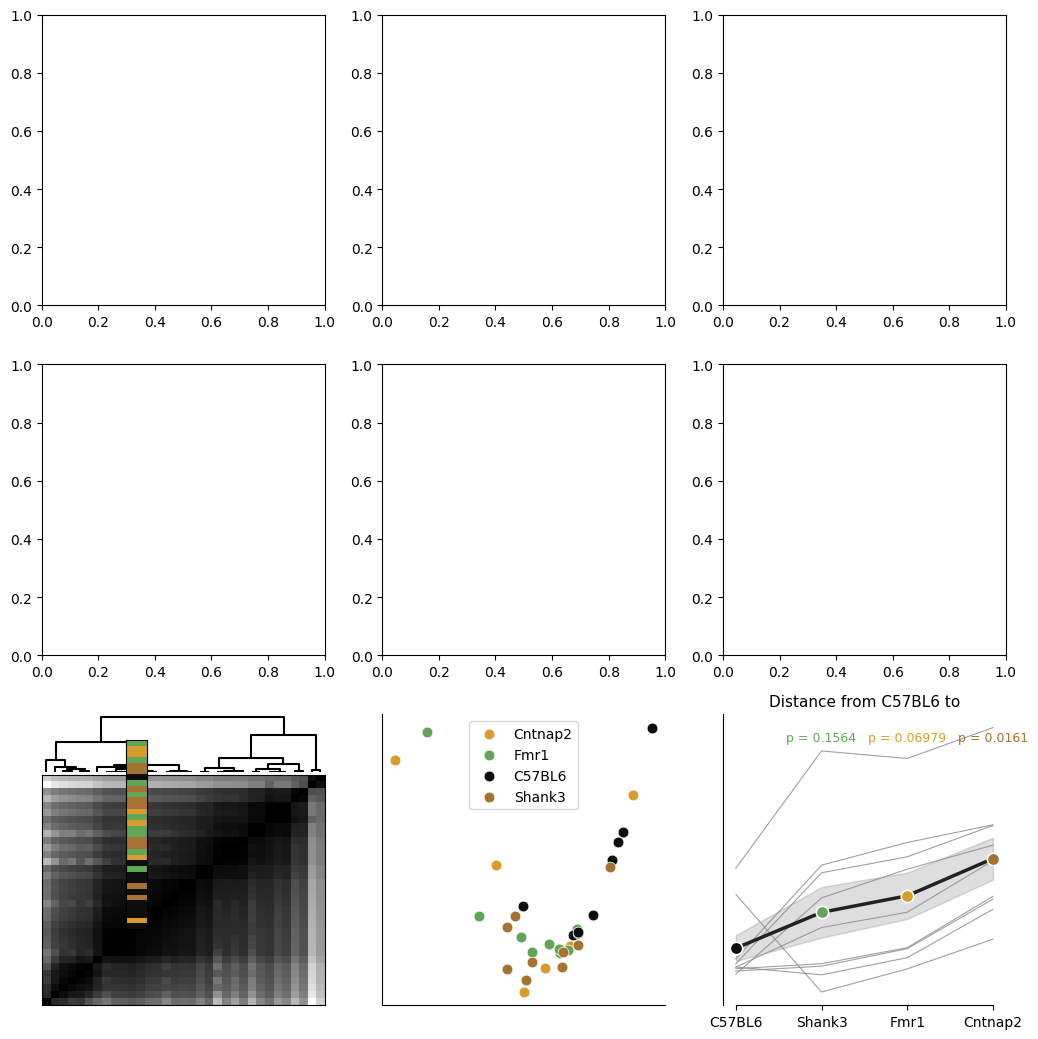

In [16]:
## Figure 6-8

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(7*1.5,7*1.5), constrained_layout=True)
axes = axes.flatten()

# FIG 6 - HIERARCHICAL CLUSTERING AND ORDERING (drawn inside axes[6])
colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}
genotypes = ['N', 'F', 'C', 'S']
contrast_names =    ['cL100', 'cL025', 'cL012', 'cL006', 'c0', 'cR006', 'cR012', 'cR025', 'cR100']

# FIG 7 - PCA (placed in axes[7])
ax_pca, _ = plot_mds_pca(dist_neural_asd, labels_arr, ax=axes[7])

# FIG 6 - ORDERED DISTANCE MATRIX + DENDROGRAM (place inside axes[6])
from scipy.cluster import hierarchy
import matplotlib.colors as mcolors
from matplotlib import gridspec

S = dist_neural_asd.shape[0]
condensed = dist_neural_asd[np.triu_indices(S,1)]
linkage = hierarchy.ward(condensed)
linkage = hierarchy.optimal_leaf_ordering(linkage, condensed)
leaf_order = hierarchy.leaves_list(linkage)
ordered_dist = dist_neural_asd[leaf_order, :][:, leaf_order]

# Replace axes[6] with two stacked subaxes (dendrogram above heatmap)
axes[6].clear()
axes[6].set_xticks([])
axes[6].set_yticks([])
sns.despine(ax=axes[6], left=True, bottom=True)
gs_inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=axes[6].get_subplotspec(), height_ratios=[1, 4], hspace=0.02)
dendro_ax = fig.add_subplot(gs_inner[0])
heatmap_ax = fig.add_subplot(gs_inner[1])

# Dendrogram (top)
dn = hierarchy.dendrogram(linkage, ax=dendro_ax, no_labels=True, color_threshold=0, above_threshold_color='k')
dendro_ax.axis('off')

# Heatmap (bottom)
heatmap_ax.imshow(ordered_dist, cmap='gray', aspect='auto', vmin=np.nanmin(ordered_dist), vmax=np.nanmax(ordered_dist), origin='lower')
heatmap_ax.set_xticks([])
heatmap_ax.set_yticks([])
for spine in heatmap_ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)

# Small genotype color strip aligned with rows of the heatmap
ordered_labels = labels_arr[leaf_order]
lab_to_color = colors
color_list = mcolors.to_rgba_array([lab_to_color[lab] for lab in ordered_labels])
pos2 = heatmap_ax.get_position()
strip_width = 0.02
pad = 0.005
new_heatmap_left = pos2.x0 + strip_width + pad
new_heatmap_width = max(pos2.width - (strip_width + pad), pos2.width * 0.5)
heatmap_ax.set_position([new_heatmap_left, pos2.y0, new_heatmap_width, pos2.height])
cax = fig.add_axes([pos2.x0, pos2.y0, strip_width, pos2.height])
cax.imshow(color_list.reshape(-1,1,4), aspect='auto', origin='lower')
cax.set_xticks([])
cax.set_yticks([])

## FIG 8 - PARALLEL T-TEST PLOT (axes[8])
cols = ['Within control', 'Control vs S', 'Control vs F', 'Control vs C']
x_labels = ['C57BL6', 'Shank3', 'Fmr1', 'Cntnap2']

for _, row in df_control_distances[cols].iterrows():
    axes[8].plot(range(len(cols)), row.values, color='#888888', alpha=0.8, linewidth=0.8, zorder=3)

means = df_control_distances[cols].mean(axis=0)
sem = df_control_distances[cols].sem(axis=0)

axes[8].fill_between(range(len(cols)), means - sem, means + sem,
                color='#222222', alpha=0.15, zorder=2)

mean_colors = ['#0D0D0D', '#61A656', '#D99C2B', '#A67232']
axes[8].plot(range(len(cols)), means.values, color='#222222', linewidth=2.5, zorder=3)

for xi, col in enumerate(cols):
    axes[8].scatter(xi, means[col], color=mean_colors[xi], s=80, zorder=4, edgecolor='white', linewidth=1.2)

results = {}
a = df_control_distances['Within control'].values
y_max_val = df_control_distances[cols].max().max()

for xi, col in enumerate(['Control vs S', 'Control vs F', 'Control vs C'], start=1):
    b = df_control_distances[col].values
    mask = (~np.isnan(a)) & (~np.isnan(b))
    if mask.sum() >= 2:
        t_stat, p_val = ttest_rel(a[mask], b[mask])
        print(t_stat, p_val)
        obs, p_val = genotype_perm_test(dist_neural_asd, labels_arr, 'N', col.split()[-1])
        print(p_val)

        results[col] = {'n': int(mask.sum()), 't': float(t_stat), 'p': float(p_val)}

        axes[8].text(xi, y_max_val - (0.05 * y_max_val), f'p = {p_val:.4g}', ha='center', va='bottom', fontsize=9, color=mean_colors[xi])

axes[8].set_xticks(range(len(cols)))
axes[8].set_xticklabels(x_labels, fontsize=10)
axes[8].set_yticks([])

axes[8].set_title('Distance from C57BL6 to', fontsize=11)

sns.despine(ax=axes[8], trim=True)
axes[8].grid(axis='y', color="#ECE9E9", linewidth=0.8, linestyle='--')
axes[8].grid(axis='x', visible=False)
axes[8].legend(frameon=False, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

### Time resolved correlation

In [ ]:

import jax.numpy as jnp
import sys
sys.path.insert(1,'./ibl_analysis/scripts/')
import utils

import matplotlib as mpl
import matplotlib.pyplot as plt

new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
mpl.rcParams.update(new_rc_params)

In [ ]:
# Taken from script 'time_resolved_corr.py'
# Takes a long time to process...
from utils import plot_time_corrs, load_and_process_fold
w, s = 10, 2
region = 'all'

# Load and process the data for response
all_corrs_resp = load_and_process_fold(region, 'response', w, s)
print("Done loading and processing response")
# same with stimulus
all_corrs_stim = load_and_process_fold(region, 'stim', w, s)
print("Done loading and processing stimulus")

# plotting the results
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,5))
all_corrs = {'response': all_corrs_resp, 'stim': all_corrs_stim}
ax = plot_time_corrs(all_corrs, ax=ax, w=w, s=s)
plt.show()

ImportError: cannot import name 'plot_time_corrs' from 'utils' (/home/blopes/ShapeMetrics/./ibl_autism/scripts/utils.py)